# Data Augmentation Adaptativo para Clasificación de Escarabajos

Este notebook implementa data augmentation adaptativo basado en la cantidad de imágenes por clase.

## Estrategia Adaptativa:
- **≤6 imágenes**: 25 variantes (transformaciones agresivas)
- **≤80 imágenes**: 15 variantes (transformaciones moderadas)
- **≤300 imágenes**: 10 variantes (transformaciones moderadas-leves)
- **≤500 imágenes**: 7 variantes (transformaciones leves)
- **>500 imágenes**: 3 variantes (transformaciones muy leves)

## Objetivo:
Balancear el dataset para mejorar el rendimiento del modelo de clasificación y reducir el sobreentrenamiento.

## Estructura de Carpetas:
- **Originales**: `cropped_beetles/images/` (no se modifican)
- **Aumentadas**: `cropped_beetles/images_augmented/` (solo aumentadas)

## 1. Importar Librerías

In [2]:
import os
import random
import numpy as np
from PIL import Image
from pathlib import Path
from collections import Counter
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torchvision
import torchvision.transforms as transforms
from torchvision.transforms import functional as TF

# Configurar seed para reproducibilidad
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print(f"PyTorch version: {torch.__version__}")
print(f"Torchvision version: {torchvision.__version__}")
print(f"Device: {'CUDA' if torch.cuda.is_available() else 'CPU'}")

PyTorch version: 2.5.1
Torchvision version: 0.20.1
Device: CUDA


## 2. Configuración del Dataset

In [3]:
# Configuración
DATA_DIR = 'cropped_beetles/images'
OUTPUT_DIR = 'cropped_beetles/images_augmented'  # Carpeta SEPARADA para aumentadas

# Configuración de augmentation adaptativo
AUGMENTATION_CONFIG = {
    'very_low': {
        'threshold': 6,
        'num_augmentations': 25,
        'level': 'aggressive'
    },
    'low': {
        'threshold': 80,
        'num_augmentations': 15,
        'level': 'moderate'
    },
    'medium': {
        'threshold': 300,
        'num_augmentations': 10,
        'level': 'moderate-light'
    },
    'high': {
        'threshold': 500,
        'num_augmentations': 7,
        'level': 'light'
    },
    'very_high': {
        'threshold': float('inf'),
        'num_augmentations': 3,  # Cambiado de 4 a 3
        'level': 'very-light'
    }
}

print("Configuración de Data Augmentation:")
print("-" * 70)
for category, config in AUGMENTATION_CONFIG.items():
    if config['threshold'] == float('inf'):
        print(f"{category.upper():15s} (> 500 imgs): {config['num_augmentations']:2d} variantes [{config['level']}]")
    else:
        print(f"{category.upper():15s} (<= {config['threshold']:3.0f} imgs): {config['num_augmentations']:2d} variantes [{config['level']}]")
print("-" * 70)

# Crear carpeta de salida si no existe
if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)
    print(f"\n✓ Carpeta creada: {OUTPUT_DIR}")
else:
    print(f"\n✓ Carpeta de salida existente: {OUTPUT_DIR}")

Configuración de Data Augmentation:
----------------------------------------------------------------------
VERY_LOW        (<=   6 imgs): 25 variantes [aggressive]
LOW             (<=  80 imgs): 15 variantes [moderate]
MEDIUM          (<= 300 imgs): 10 variantes [moderate-light]
HIGH            (<= 500 imgs):  7 variantes [light]
VERY_HIGH       (> 500 imgs):  3 variantes [very-light]
----------------------------------------------------------------------

✓ Carpeta creada: cropped_beetles/images_augmented


## 3. Analizar Dataset Original

In [4]:
def analyze_dataset(data_dir, only_original=True):
    """
    Analiza la distribución del dataset
    
    Args:
        data_dir: Directorio a analizar
        only_original: Si True, solo cuenta imágenes originales (sin _aug_)
    """
    class_distribution = {}
    
    for class_name in sorted(os.listdir(data_dir)):
        class_path = os.path.join(data_dir, class_name)
        
        if not os.path.isdir(class_path):
            continue
        
        # Contar imágenes (jpg, jpeg, png)
        image_files = [f for f in os.listdir(class_path) 
                      if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        
        # Filtrar solo originales si se solicita
        if only_original:
            image_files = [f for f in image_files if '_aug_' not in f]
        
        class_distribution[class_name] = len(image_files)
    
    return class_distribution

# Analizar dataset ORIGINAL (sin aumentadas previas)
class_dist = analyze_dataset(DATA_DIR, only_original=True)

print("Distribución Original del Dataset (SOLO ORIGINALES):")
print("-" * 60)
for class_name, count in sorted(class_dist.items(), key=lambda x: x[1]):
    print(f"{class_name:35s}: {count:4d} imágenes")
print("-" * 60)
print(f"Total de géneros: {len(class_dist)}")
print(f"Total de imágenes originales: {sum(class_dist.values())}")
print(f"Promedio por clase: {np.mean(list(class_dist.values())):.1f}")
print(f"Mediana por clase: {np.median(list(class_dist.values())):.1f}")
print(f"Min: {min(class_dist.values())}, Max: {max(class_dist.values())}")

Distribución Original del Dataset (SOLO ORIGINALES):
------------------------------------------------------------
canthidium_02h                     :    2 imágenes
canthon_08h                        :    2 imágenes
phanaeus_hermes                    :    3 imágenes
aphodinae_                         :    4 imágenes
canthon_subhyalinus                :    4 imágenes
canthon_x                          :    4 imágenes
coprophanaeus_gamezzi              :    4 imágenes
dichotomios_germanamati            :    4 imágenes
pseuducanthon_perplexus            :    4 imágenes
ontophagus_transistmius            :    6 imágenes
sylvicanthon_aequinoctialis        :   15 imágenes
ontophagus_marginicolis            :   26 imágenes
ateuchus_                          :   42 imágenes
dichotomius_agenor                 :   48 imágenes
coprophanaeus_corythus             :   50 imágenes
eurysternus_impressicolis          :   50 imágenes
eurysternus_mexicanus              :   56 imágenes
dicothomios_       

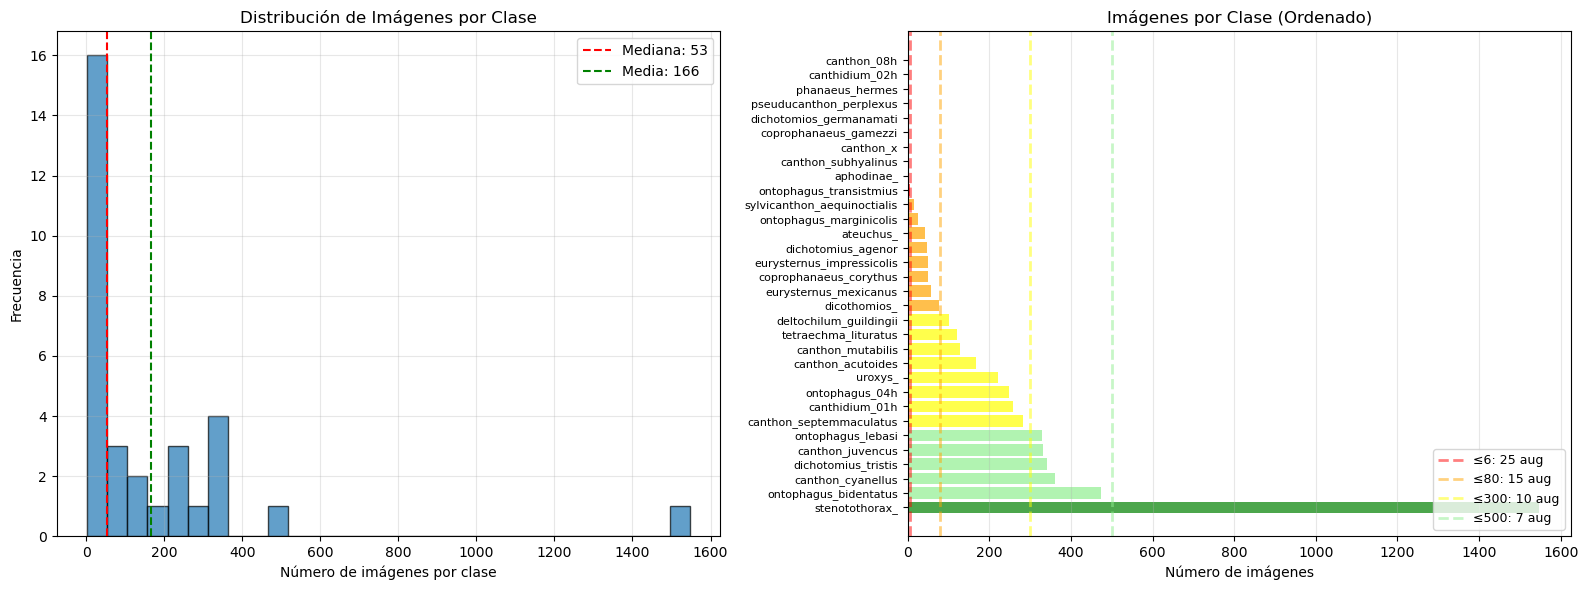

In [5]:
# Visualizar distribución
plt.figure(figsize=(16, 6))

# Histograma
plt.subplot(1, 2, 1)
counts = list(class_dist.values())
plt.hist(counts, bins=30, edgecolor='black', alpha=0.7)
plt.xlabel('Número de imágenes por clase')
plt.ylabel('Frecuencia')
plt.title('Distribución de Imágenes por Clase')
plt.axvline(np.median(counts), color='red', linestyle='--', label=f'Mediana: {np.median(counts):.0f}')
plt.axvline(np.mean(counts), color='green', linestyle='--', label=f'Media: {np.mean(counts):.0f}')
plt.legend()
plt.grid(True, alpha=0.3)

# Barplot ordenado
plt.subplot(1, 2, 2)
sorted_classes = sorted(class_dist.items(), key=lambda x: x[1], reverse=True)
class_names = [c[0] for c in sorted_classes]
class_counts = [c[1] for c in sorted_classes]

colors = ['red' if c <= 6 else 'orange' if c <= 80 else 'yellow' if c <= 300 else 'lightgreen' if c <= 500 else 'green' 
          for c in class_counts]

plt.barh(range(len(class_names)), class_counts, color=colors, alpha=0.7)
plt.yticks(range(len(class_names)), class_names, fontsize=8)
plt.xlabel('Número de imágenes')
plt.title('Imágenes por Clase (Ordenado)')
plt.axvline(6, color='red', linestyle='--', alpha=0.5, linewidth=2, label='≤6: 25 aug')
plt.axvline(80, color='orange', linestyle='--', alpha=0.5, linewidth=2, label='≤80: 15 aug')
plt.axvline(300, color='yellow', linestyle='--', alpha=0.5, linewidth=2, label='≤300: 10 aug')
plt.axvline(500, color='lightgreen', linestyle='--', alpha=0.5, linewidth=2, label='≤500: 7 aug')
plt.legend(loc='lower right', fontsize=9)
plt.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

## 4. Definir Transformaciones Adaptativas

In [6]:
class AdaptiveAugmentation:
    """
    Clase para aplicar transformaciones adaptativas según el nivel de datos.
    """
    
    def __init__(self, level='moderate'):
        self.level = level
        self.base_size = 224
        
    def get_aggressive_transforms(self):
        """Transformaciones agresivas para clases con muy pocas imágenes (≤6)"""
        return [
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomVerticalFlip(p=0.3),
            transforms.RandomRotation(degrees=30),
            transforms.RandomAffine(
                degrees=20,
                translate=(0.15, 0.15),
                scale=(0.8, 1.2),
                shear=15
            ),
            transforms.ColorJitter(
                brightness=0.4,
                contrast=0.4,
                saturation=0.4,
                hue=0.2
            ),
            transforms.RandomPerspective(distortion_scale=0.3, p=0.5),
            transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
            transforms.RandomAdjustSharpness(sharpness_factor=2, p=0.3),
        ]
    
    def get_moderate_transforms(self):
        """Transformaciones moderadas para clases con pocas imágenes (≤80)"""
        return [
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomVerticalFlip(p=0.2),
            transforms.RandomRotation(degrees=20),
            transforms.RandomAffine(
                degrees=15,
                translate=(0.1, 0.1),
                scale=(0.85, 1.15),
                shear=10
            ),
            transforms.ColorJitter(
                brightness=0.3,
                contrast=0.3,
                saturation=0.3,
                hue=0.1
            ),
            transforms.RandomPerspective(distortion_scale=0.2, p=0.3),
            transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.5)),
        ]
    
    def get_moderate_light_transforms(self):
        """Transformaciones moderadas-leves para clases con cantidad media (≤300)"""
        return [
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomRotation(degrees=15),
            transforms.RandomAffine(
                degrees=10,
                translate=(0.08, 0.08),
                scale=(0.9, 1.1),
                shear=5
            ),
            transforms.ColorJitter(
                brightness=0.2,
                contrast=0.2,
                saturation=0.2,
                hue=0.05
            ),
            transforms.RandomPerspective(distortion_scale=0.15, p=0.2),
        ]
    
    def get_light_transforms(self):
        """Transformaciones leves para clases con bastantes imágenes (≤500)"""
        return [
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomRotation(degrees=10),
            transforms.ColorJitter(
                brightness=0.15,
                contrast=0.15,
                saturation=0.15,
                hue=0.03
            ),
            transforms.RandomAffine(
                degrees=5,
                translate=(0.05, 0.05),
                scale=(0.95, 1.05)
            ),
        ]
    
    def get_very_light_transforms(self):
        """Transformaciones muy leves para clases con muchas imágenes (>500)"""
        return [
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomRotation(degrees=8),
            transforms.ColorJitter(
                brightness=0.1,
                contrast=0.1,
                saturation=0.1,
                hue=0.02
            ),
            transforms.RandomAffine(
                degrees=3,
                translate=(0.03, 0.03),
                scale=(0.97, 1.03)
            ),
        ]
    
    def get_transforms(self):
        """Obtener las transformaciones según el nivel"""
        if self.level == 'aggressive':
            return self.get_aggressive_transforms()
        elif self.level == 'moderate':
            return self.get_moderate_transforms()
        elif self.level == 'moderate-light':
            return self.get_moderate_light_transforms()
        elif self.level == 'light':
            return self.get_light_transforms()
        else:  # very-light
            return self.get_very_light_transforms()
    
    def apply_random_transform(self, image):
        """
        Aplica una combinación aleatoria de transformaciones
        """
        transforms_list = self.get_transforms()
        
        # Seleccionar aleatoriamente un subconjunto de transformaciones
        if self.level == 'aggressive':
            num_transforms = random.randint(4, 6)
        elif self.level == 'moderate':
            num_transforms = random.randint(3, 5)
        elif self.level == 'moderate-light':
            num_transforms = random.randint(2, 4)
        elif self.level == 'light':
            num_transforms = random.randint(2, 3)
        else:  # very-light
            num_transforms = random.randint(2, 3)
        
        selected_transforms = random.sample(transforms_list, 
                                           min(num_transforms, len(transforms_list)))
        
        # Aplicar transformaciones
        for transform in selected_transforms:
            try:
                image = transform(image)
            except Exception as e:
                print(f"Warning: Transform failed - {e}")
                continue
        
        return image

print("✓ Clase AdaptiveAugmentation definida")

✓ Clase AdaptiveAugmentation definida


## 5. Función de Augmentation con Validación de Calidad

In [7]:
def is_valid_image(image, min_size=50):
    """
    Valida que la imagen generada tenga calidad aceptable
    """
    if image is None:
        return False
    
    # Verificar tamaño mínimo
    width, height = image.size
    if width < min_size or height < min_size:
        return False
    
    # Verificar que no sea completamente negra o blanca
    img_array = np.array(image)
    mean_value = np.mean(img_array)
    if mean_value < 10 or mean_value > 245:
        return False
    
    # Verificar varianza (detectar imágenes muy uniformes)
    variance = np.var(img_array)
    if variance < 100:  # Imagen muy uniforme
        return False
    
    return True


def get_augmentation_level(num_images):
    """Determina el nivel de augmentation según el número de imágenes"""
    for category, config in AUGMENTATION_CONFIG.items():
        if num_images <= config['threshold']:
            return config['level'], config['num_augmentations']
    return 'light', 5


def augment_class_images(class_name, class_path, output_path, num_images):
    """
    Aumenta las imágenes de una clase específica
    
    Args:
        class_name: Nombre de la clase
        class_path: Ruta de entrada (imágenes originales)
        output_path: Ruta de salida (imágenes aumentadas)
        num_images: Número de imágenes originales
    """
    # Determinar nivel de augmentation
    level, num_augmentations = get_augmentation_level(num_images)
    
    # Crear augmentador
    augmentor = AdaptiveAugmentation(level=level)
    
    # Obtener SOLO imágenes originales (sin _aug_)
    all_files = os.listdir(class_path)
    image_files = [f for f in all_files 
                   if f.lower().endswith(('.jpg', '.jpeg', '.png')) 
                   and '_aug_' not in f]  # Filtrar aumentadas previas
    
    if len(image_files) == 0:
        print(f"⚠️  {class_name}: No se encontraron imágenes originales")
        return 0, 0
    
    # Asegurar que el directorio de salida existe
    os.makedirs(output_path, exist_ok=True)
    
    augmented_count = 0
    failed_count = 0
    
    # Barra de progreso para esta clase
    pbar = tqdm(total=len(image_files) * num_augmentations, 
                desc=f"{class_name[:30]:30s} [{level:15s}]", 
                leave=False)
    
    for img_file in image_files:
        img_path = os.path.join(class_path, img_file)
        
        try:
            # Cargar imagen original
            original_img = Image.open(img_path).convert('RGB')
            
            # Validar imagen original
            if not is_valid_image(original_img):
                print(f"⚠️  Imagen inválida: {img_file}")
                continue
            
            # Generar variantes aumentadas
            for aug_idx in range(num_augmentations):
                try:
                    # Aplicar transformaciones
                    augmented_img = augmentor.apply_random_transform(original_img.copy())
                    
                    # Validar imagen aumentada
                    if not is_valid_image(augmented_img):
                        failed_count += 1
                        pbar.update(1)
                        continue
                    
                    # Generar nombre de archivo único
                    base_name = os.path.splitext(img_file)[0]
                    ext = os.path.splitext(img_file)[1]
                    aug_filename = f"{base_name}_aug_{aug_idx:03d}{ext}"
                    aug_path = os.path.join(output_path, aug_filename)
                    
                    # Guardar imagen aumentada
                    augmented_img.save(aug_path, quality=95)
                    augmented_count += 1
                    
                except Exception as e:
                    failed_count += 1
                    print(f"Error augmentando {img_file} (variant {aug_idx}): {e}")
                
                pbar.update(1)
        
        except Exception as e:
            print(f"Error cargando {img_file}: {e}")
            continue
    
    pbar.close()
    
    return augmented_count, failed_count


print("✓ Funciones de augmentation definidas")

✓ Funciones de augmentation definidas


## 6. Previsualización de Augmentation (Ejemplo)

🔍 PREVISUALIZACIÓN DE AUGMENTATION



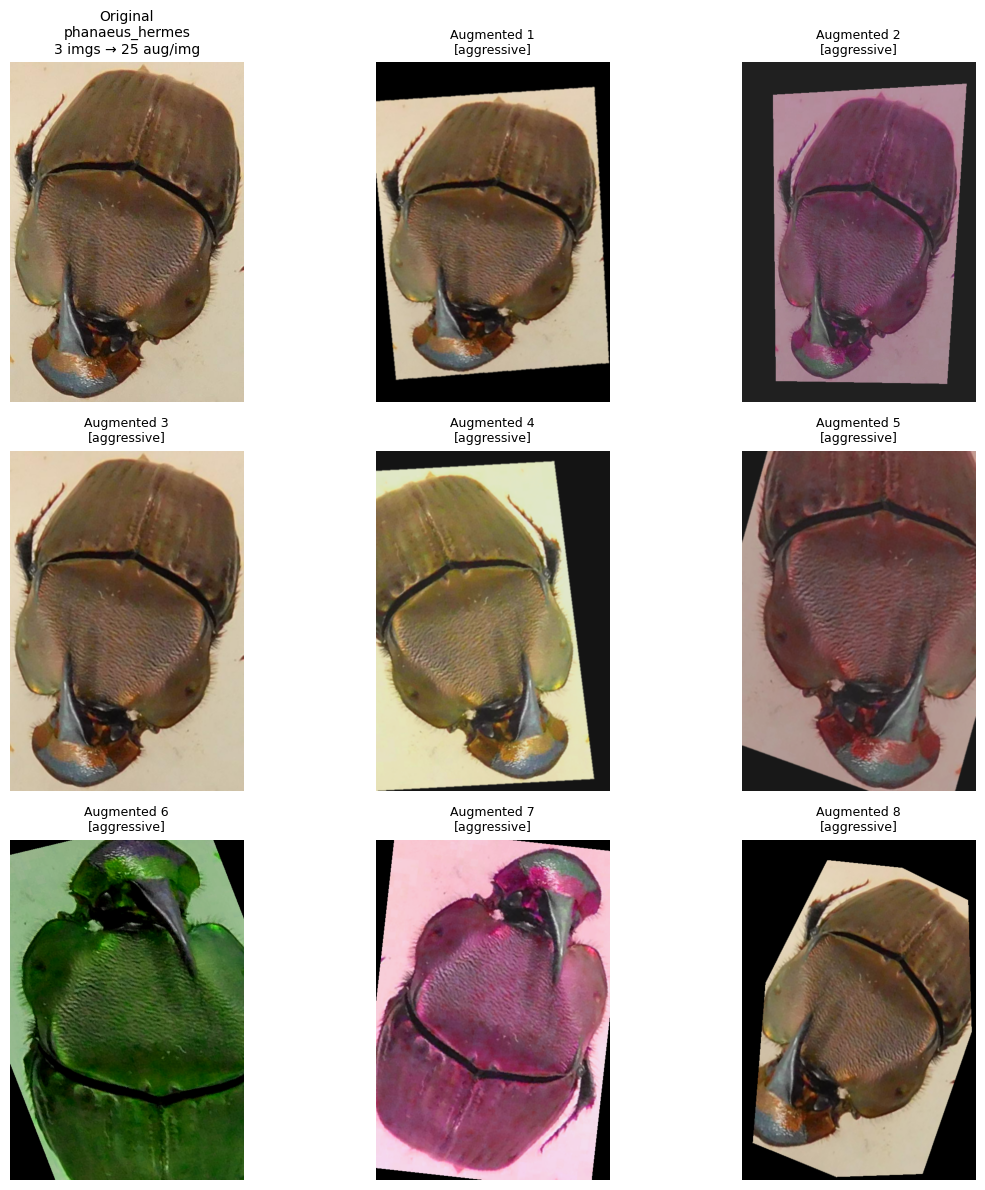

Clase: phanaeus_hermes
Imágenes originales: 3
Nivel de augmentation: aggressive
Variantes por imagen: 25
Total imágenes después: 78
------------------------------------------------------------


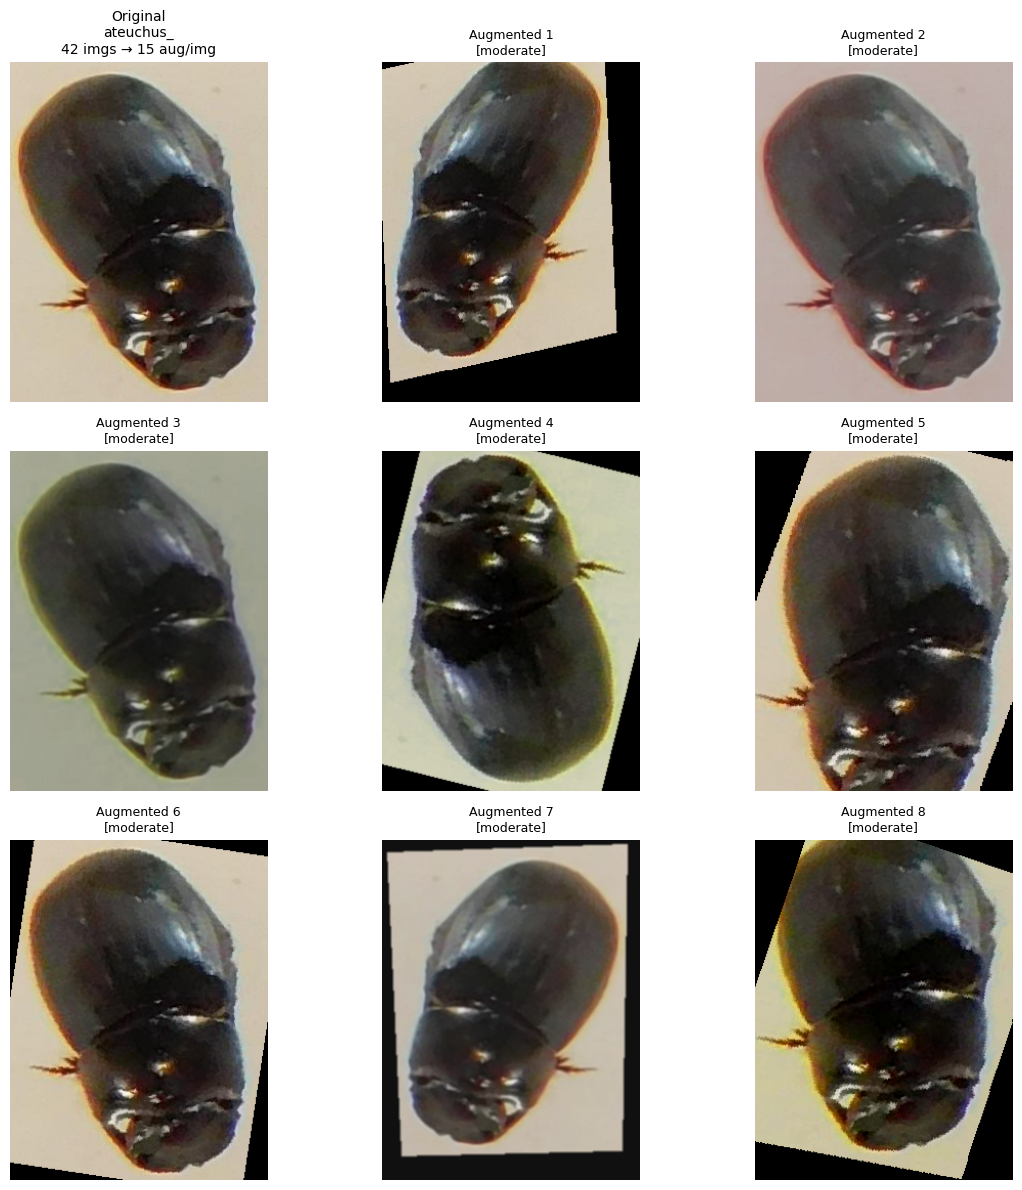

Clase: ateuchus_
Imágenes originales: 42
Nivel de augmentation: moderate
Variantes por imagen: 15
Total imágenes después: 672
------------------------------------------------------------


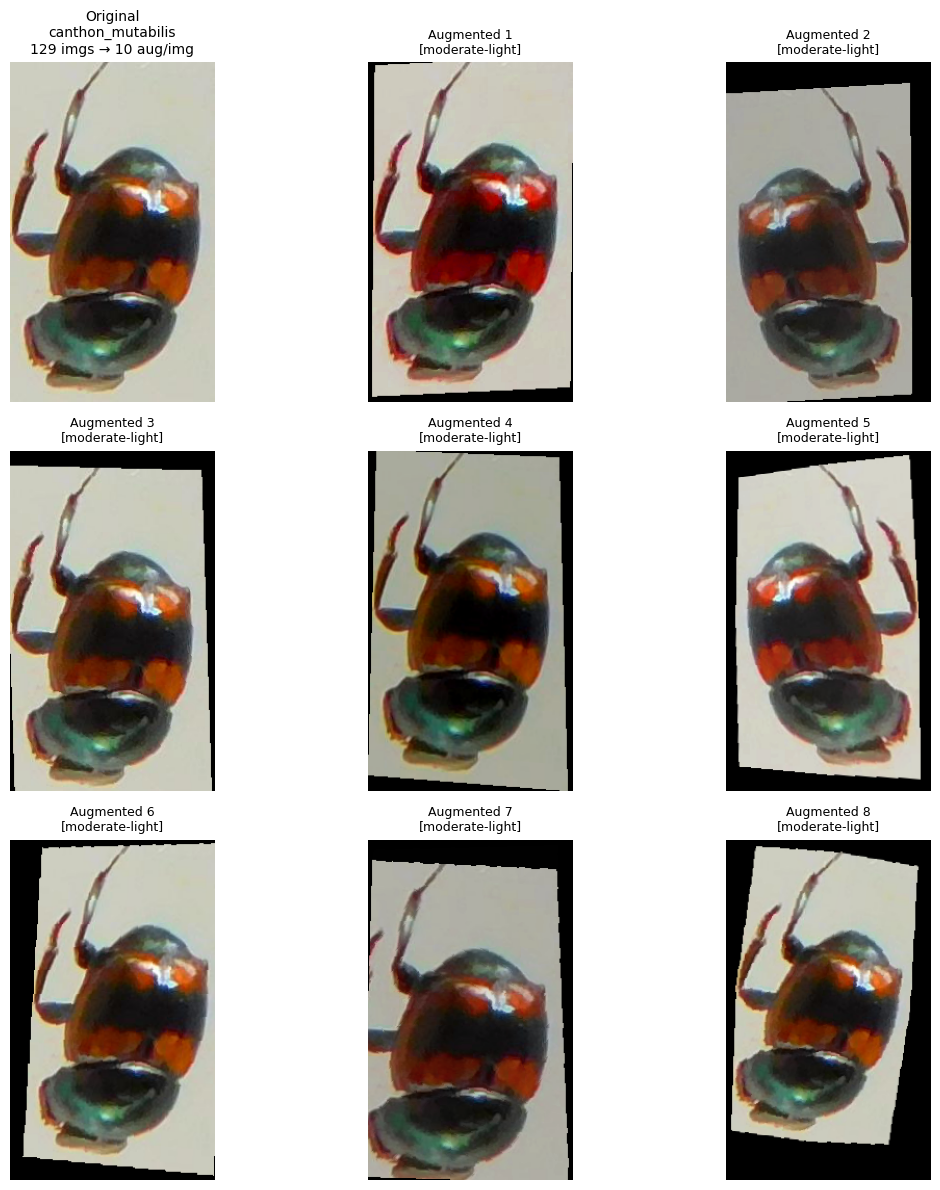

Clase: canthon_mutabilis
Imágenes originales: 129
Nivel de augmentation: moderate-light
Variantes por imagen: 10
Total imágenes después: 1419
------------------------------------------------------------


In [8]:
def preview_augmentations(class_name, num_samples=8):
    """
    Previsualiza las transformaciones para una clase específica
    """
    class_path = os.path.join(DATA_DIR, class_name)
    
    # Obtener una imagen de ejemplo
    image_files = [f for f in os.listdir(class_path) 
                   if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    
    if len(image_files) == 0:
        print(f"No se encontraron imágenes en {class_name}")
        return
    
    # Cargar imagen original
    img_path = os.path.join(class_path, image_files[0])
    original_img = Image.open(img_path).convert('RGB')
    
    # Determinar nivel de augmentation
    num_images = len(image_files)
    level, num_aug = get_augmentation_level(num_images)
    
    # Crear augmentador
    augmentor = AdaptiveAugmentation(level=level)
    
    # Generar variantes
    fig, axes = plt.subplots(3, 3, figsize=(12, 12))
    axes = axes.flatten()
    
    # Mostrar original
    axes[0].imshow(original_img)
    axes[0].set_title(f'Original\n{class_name}\n{num_images} imgs → {num_aug} aug/img', 
                      fontsize=10)
    axes[0].axis('off')
    
    # Generar y mostrar variantes
    for i in range(1, 9):
        augmented = augmentor.apply_random_transform(original_img.copy())
        axes[i].imshow(augmented)
        axes[i].set_title(f'Augmented {i}\n[{level}]', fontsize=9)
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    print(f"Clase: {class_name}")
    print(f"Imágenes originales: {num_images}")
    print(f"Nivel de augmentation: {level}")
    print(f"Variantes por imagen: {num_aug}")
    print(f"Total imágenes después: {num_images * (1 + num_aug)}")
    print("-" * 60)

# Previsualizar algunas clases representativas
print("🔍 PREVISUALIZACIÓN DE AUGMENTATION\n")

# Clase con muy pocas imágenes (aggressive)
if 'phanaeus_hermes' in class_dist:
    preview_augmentations('phanaeus_hermes')

# Clase con pocas imágenes (moderate)
if 'ateuchus_' in class_dist:
    preview_augmentations('ateuchus_')

# Clase con cantidad media (moderate-light)
if 'canthon_mutabilis' in class_dist:
    preview_augmentations('canthon_mutabilis')

## 7. Ejecutar Data Augmentation para Todo el Dataset

In [9]:
def augment_entire_dataset(data_dir, output_dir):
    """
    Aplica data augmentation a todo el dataset
    Guarda las imágenes aumentadas en una carpeta separada
    """
    print("=" * 80)
    print("INICIANDO DATA AUGMENTATION ADAPTATIVO")
    print("=" * 80)
    print(f"📁 Entrada:  {data_dir}")
    print(f"📁 Salida:   {output_dir}")
    print("=" * 80)
    
    # Estadísticas globales
    total_original = 0
    total_augmented = 0
    total_failed = 0
    results = []
    
    # Obtener todas las clases
    class_folders = sorted([f for f in os.listdir(data_dir) 
                           if os.path.isdir(os.path.join(data_dir, f))])
    
    print(f"\n📊 Procesando {len(class_folders)} clases...\n")
    
    # Procesar cada clase
    for class_name in class_folders:
        class_path = os.path.join(data_dir, class_name)
        output_path = os.path.join(output_dir, class_name)
        
        # Contar SOLO imágenes originales (sin _aug_)
        all_files = os.listdir(class_path)
        original_files = [f for f in all_files 
                         if f.lower().endswith(('.jpg', '.jpeg', '.png'))
                         and '_aug_' not in f]
        num_images = len(original_files)
        
        if num_images == 0:
            continue
        
        total_original += num_images
        
        # Aplicar augmentation
        augmented, failed = augment_class_images(
            class_name, class_path, output_path, num_images
        )
        
        total_augmented += augmented
        total_failed += failed
        
        # Guardar resultados
        level, num_aug = get_augmentation_level(num_images)
        results.append({
            'class': class_name,
            'original': num_images,
            'augmented': augmented,
            'failed': failed,
            'total': num_images + augmented,
            'level': level,
            'num_aug_per_img': num_aug
        })
    
    print("\n" + "=" * 80)
    print("RESUMEN DEL PROCESO")
    print("=" * 80)
    print(f"✓ Imágenes originales: {total_original:,}")
    print(f"✓ Imágenes generadas: {total_augmented:,}")
    print(f"✗ Imágenes fallidas: {total_failed:,}")
    print(f"📊 Total final: {total_original + total_augmented:,}")
    print(f"📈 Factor de aumento: {(total_original + total_augmented) / total_original:.2f}x")
    print("=" * 80)
    print(f"\n📁 Las imágenes aumentadas están en: {output_dir}")
    print(f"📁 Las imágenes originales permanecen en: {data_dir}")
    print("=" * 80)
    
    return results


# ADVERTENCIA: Este proceso puede tomar bastante tiempo dependiendo del tamaño del dataset
print("=" * 80)
print("⚠️  INFORMACIÓN IMPORTANTE")
print("=" * 80)
print(f"✓ Este proceso generará imágenes aumentadas")
print(f"✓ Las originales permanecerán en:  {DATA_DIR}")
print(f"✓ Las aumentadas se guardarán en:  {OUTPUT_DIR}")
print(f"✓ Clases con >500 imgs: 3 variantes por imagen")
print("=" * 80)
print()
response = input("¿Deseas continuar? (si/no): ")

if response.lower() in ['si', 'sí', 's', 'yes', 'y']:
    import time
    start_time = time.time()
    
    results = augment_entire_dataset(DATA_DIR, OUTPUT_DIR)
    
    elapsed_time = time.time() - start_time
    print(f"\n⏱️  Tiempo total: {elapsed_time/60:.2f} minutos")
else:
    print("❌ Proceso cancelado")
    results = None

⚠️  INFORMACIÓN IMPORTANTE
✓ Este proceso generará imágenes aumentadas
✓ Las originales permanecerán en:  cropped_beetles/images
✓ Las aumentadas se guardarán en:  cropped_beetles/images_augmented
✓ Clases con >500 imgs: 3 variantes por imagen

INICIANDO DATA AUGMENTATION ADAPTATIVO
📁 Entrada:  cropped_beetles/images
📁 Salida:   cropped_beetles/images_augmented

📊 Procesando 32 clases...

INICIANDO DATA AUGMENTATION ADAPTATIVO
📁 Entrada:  cropped_beetles/images
📁 Salida:   cropped_beetles/images_augmented

📊 Procesando 32 clases...



aphodinae_                     [aggressive     ]:   0%|          | 0/100 [00:00<?, ?it/s]

ateuchus_                      [moderate       ]:   0%|          | 0/630 [00:00<?, ?it/s]

canthidium_01h                 [moderate-light ]:   0%|          | 0/2570 [00:00<?, ?it/s]

canthidium_02h                 [aggressive     ]:   0%|          | 0/50 [00:00<?, ?it/s]

...

stenotothorax_                 [very-light     ]:   0%|          | 0/4644 [00:00<?, ?it/s]

sylvicanthon_aequinoctialis    [moderate       ]:   0%|          | 0/225 [00:00<?, ?it/s]

tetraechma_lituratus           [moderate-light ]:   0%|          | 0/1200 [00:00<?, ?it/s]

uroxys_                        [moderate-light ]:   0%|          | 0/2220 [00:00<?, ?it/s]


RESUMEN DEL PROCESO
✓ Imágenes originales: 5,310
✓ Imágenes generadas: 39,123
✗ Imágenes fallidas: 0
📊 Total final: 44,433
📈 Factor de aumento: 8.37x

📁 Las imágenes aumentadas están en: cropped_beetles/images_augmented
📁 Las imágenes originales permanecen en: cropped_beetles/images

⏱️  Tiempo total: 12.13 minutos


## 8. Análisis de Resultados Post-Augmentation


📊 RESULTADOS DETALLADOS POR CLASE
Clase                               Original  Generadas    Total  Factor           Nivel
----------------------------------------------------------------------------------------------------
canthidium_02h                             2         50       52    26.0x      aggressive
canthon_08h                                2         50       52    26.0x      aggressive
phanaeus_hermes                            3         75       78    26.0x      aggressive
aphodinae_                                 4        100      104    26.0x      aggressive
pseuducanthon_perplexus                    4        100      104    26.0x      aggressive
coprophanaeus_gamezzi                      4        100      104    26.0x      aggressive
canthon_x                                  4        100      104    26.0x      aggressive
canthon_subhyalinus                        4        100      104    26.0x      aggressive
dichotomios_germanamati                    4        100

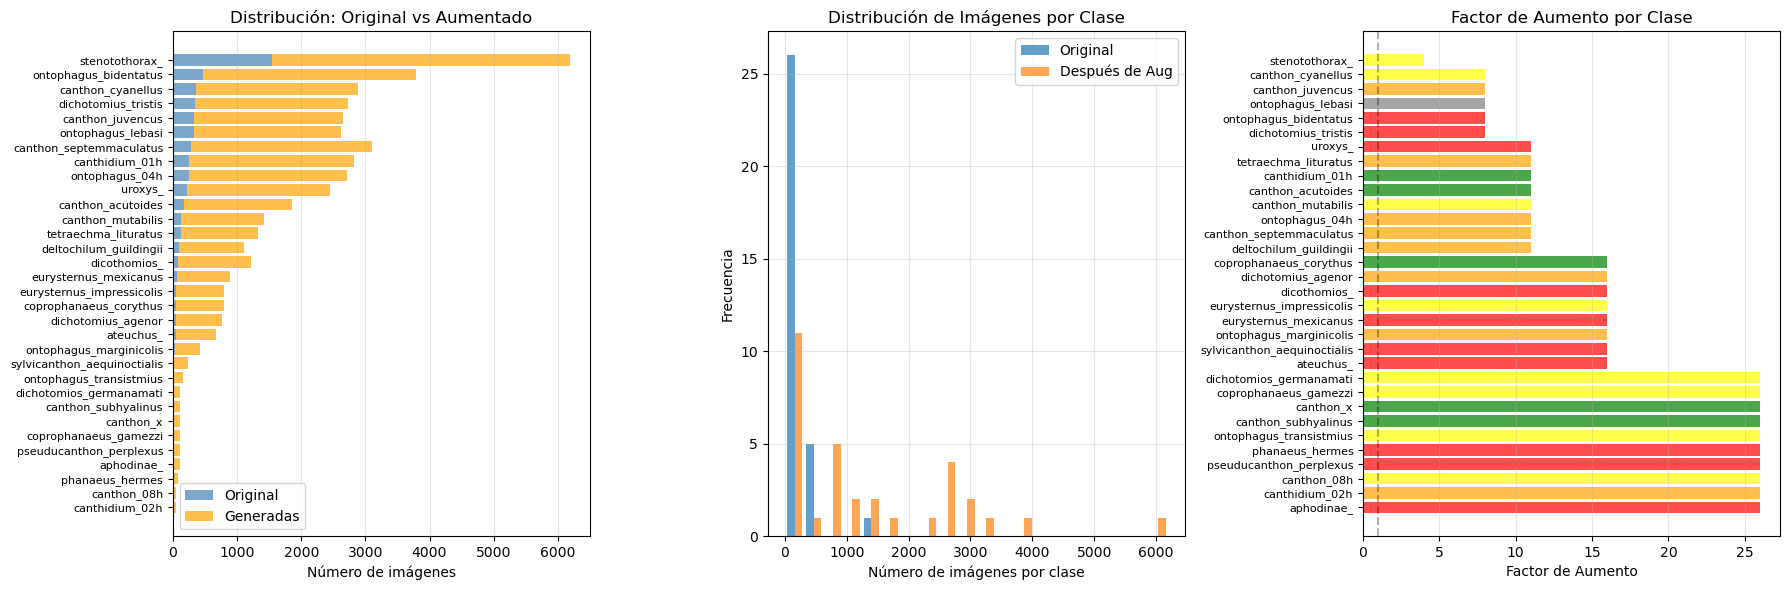


📊 MÉTRICAS DE BALANCE DEL DATASET
------------------------------------------------------------
Desviación estándar (antes): 286.8
Desviación estándar (después): 1448.7
Coeficiente de variación (antes): 1.73
Coeficiente de variación (después): 1.04
Rango (antes): 2 - 1548
Rango (después): 52 - 6192
------------------------------------------------------------

✓ Resultados guardados en 'augmentation_results.csv'


In [10]:
if results is not None:
    import pandas as pd
    
    # Crear DataFrame
    df_results = pd.DataFrame(results)
    
    # Mostrar tabla de resultados
    print("\n📊 RESULTADOS DETALLADOS POR CLASE")
    print("=" * 100)
    print(f"{'Clase':35s} {'Original':>8s} {'Generadas':>10s} {'Total':>8s} {'Factor':>7s} {'Nivel':>15s}")
    print("-" * 100)
    
    for _, row in df_results.sort_values('original').iterrows():
        factor = row['total'] / row['original'] if row['original'] > 0 else 0
        print(f"{row['class']:35s} {row['original']:8d} {row['augmented']:10d} {row['total']:8d} "
              f"{factor:7.1f}x {row['level']:>15s}")
    
    print("=" * 100)
    
    # Estadísticas por nivel
    print("\n📈 ESTADÍSTICAS POR NIVEL DE AUGMENTATION")
    print("-" * 60)
    level_stats = df_results.groupby('level').agg({
        'original': 'sum',
        'augmented': 'sum',
        'total': 'sum'
    })
    
    for level, stats in level_stats.iterrows():
        factor = stats['total'] / stats['original'] if stats['original'] > 0 else 0
        print(f"{level:15s}: {stats['original']:5.0f} → {stats['total']:6.0f} imágenes ({factor:.1f}x)")
    
    print("-" * 60)
    
    # Visualización comparativa
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    # Gráfico 1: Antes vs Después
    ax1 = axes[0]
    sorted_df = df_results.sort_values('original')
    x = range(len(sorted_df))
    ax1.barh(x, sorted_df['original'], alpha=0.7, label='Original', color='steelblue')
    ax1.barh(x, sorted_df['augmented'], left=sorted_df['original'], 
             alpha=0.7, label='Generadas', color='orange')
    ax1.set_yticks(x)
    ax1.set_yticklabels(sorted_df['class'], fontsize=8)
    ax1.set_xlabel('Número de imágenes')
    ax1.set_title('Distribución: Original vs Aumentado')
    ax1.legend()
    ax1.grid(True, alpha=0.3, axis='x')
    
    # Gráfico 2: Comparación de distribuciones
    ax2 = axes[1]
    ax2.hist([df_results['original'], df_results['total']], 
             bins=20, label=['Original', 'Después de Aug'], alpha=0.7)
    ax2.set_xlabel('Número de imágenes por clase')
    ax2.set_ylabel('Frecuencia')
    ax2.set_title('Distribución de Imágenes por Clase')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # Gráfico 3: Factor de aumento por clase
    ax3 = axes[2]
    df_results['factor'] = df_results['total'] / df_results['original']
    colors_map = {
        'aggressive': 'red',
        'moderate': 'orange',
        'moderate-light': 'yellow',
        'light': 'green'
    }
    colors = [colors_map.get(level, 'gray') for level in df_results['level']]
    
    sorted_by_factor = df_results.sort_values('factor', ascending=False)
    ax3.barh(range(len(sorted_by_factor)), sorted_by_factor['factor'], color=colors, alpha=0.7)
    ax3.set_yticks(range(len(sorted_by_factor)))
    ax3.set_yticklabels(sorted_by_factor['class'], fontsize=8)
    ax3.set_xlabel('Factor de Aumento')
    ax3.set_title('Factor de Aumento por Clase')
    ax3.axvline(1, color='black', linestyle='--', alpha=0.3)
    ax3.grid(True, alpha=0.3, axis='x')
    
    plt.tight_layout()
    plt.show()
    
    # Métricas de balance
    print("\n📊 MÉTRICAS DE BALANCE DEL DATASET")
    print("-" * 60)
    print(f"Desviación estándar (antes): {df_results['original'].std():.1f}")
    print(f"Desviación estándar (después): {df_results['total'].std():.1f}")
    print(f"Coeficiente de variación (antes): {df_results['original'].std() / df_results['original'].mean():.2f}")
    print(f"Coeficiente de variación (después): {df_results['total'].std() / df_results['total'].mean():.2f}")
    print(f"Rango (antes): {df_results['original'].min()} - {df_results['original'].max()}")
    print(f"Rango (después): {df_results['total'].min()} - {df_results['total'].max()}")
    print("-" * 60)
    
    # Guardar resultados
    df_results.to_csv('augmentation_results.csv', index=False)
    print("\n✓ Resultados guardados en 'augmentation_results.csv'")
else:
    print("⚠️  No hay resultados para analizar. Ejecuta primero el proceso de augmentation.")

## 9. Verificación Final del Dataset Aumentado

In [11]:
# Verificar el dataset final en la carpeta de aumentadas
final_distribution = analyze_dataset(OUTPUT_DIR, only_original=False)

print("\n🎯 DISTRIBUCIÓN FINAL DEL DATASET AUMENTADO")
print("=" * 80)
print(f"{'Clase':35s} {'Imágenes':>10s}")
print("-" * 80)
for class_name, count in sorted(final_distribution.items(), key=lambda x: x[1]):
    print(f"{class_name:35s} {count:10d}")
print("-" * 80)
print(f"Total de géneros: {len(final_distribution)}")
print(f"Total de imágenes aumentadas: {sum(final_distribution.values()):,}")
print(f"Promedio por clase: {np.mean(list(final_distribution.values())):.1f}")
print(f"Mediana por clase: {np.median(list(final_distribution.values())):.1f}")
print(f"Desviación estándar: {np.std(list(final_distribution.values())):.1f}")
print(f"Min: {min(final_distribution.values())}, Max: {max(final_distribution.values())}")
print("=" * 80)
print(f"\n📂 Carpeta originales: {DATA_DIR}")
print(f"📂 Carpeta aumentadas: {OUTPUT_DIR}")


🎯 DISTRIBUCIÓN FINAL DEL DATASET AUMENTADO
Clase                                 Imágenes
--------------------------------------------------------------------------------
canthidium_02h                              50
canthon_08h                                 50
phanaeus_hermes                             75
aphodinae_                                 100
canthon_subhyalinus                        100
canthon_x                                  100
coprophanaeus_gamezzi                      100
dichotomios_germanamati                    100
pseuducanthon_perplexus                    100
ontophagus_transistmius                    150
sylvicanthon_aequinoctialis                225
ontophagus_marginicolis                    390
ateuchus_                                  630
dichotomius_agenor                         720
coprophanaeus_corythus                     750
eurysternus_impressicolis                  750
eurysternus_mexicanus                      840
deltochilum_guildingii       

## 10. Visualización de Muestras Aleatorias del Dataset Aumentado

🖼️  VISUALIZACIÓN DE MUESTRAS AUMENTADAS



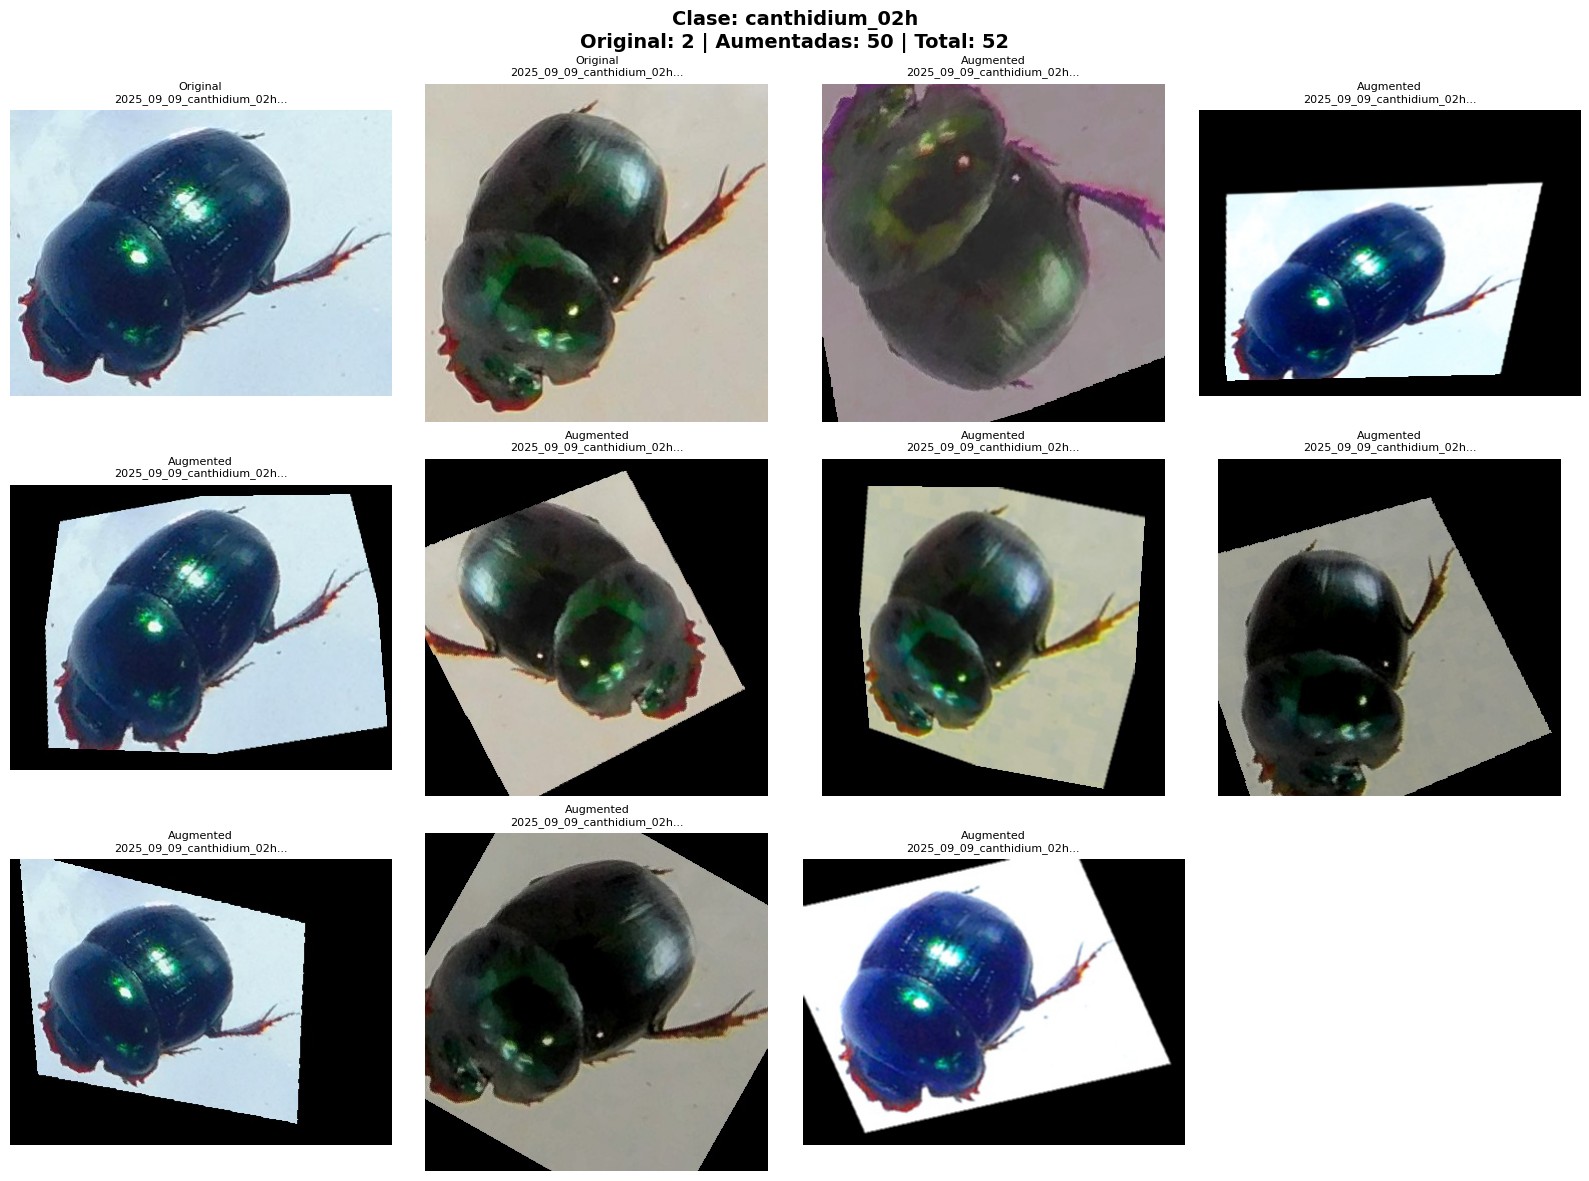

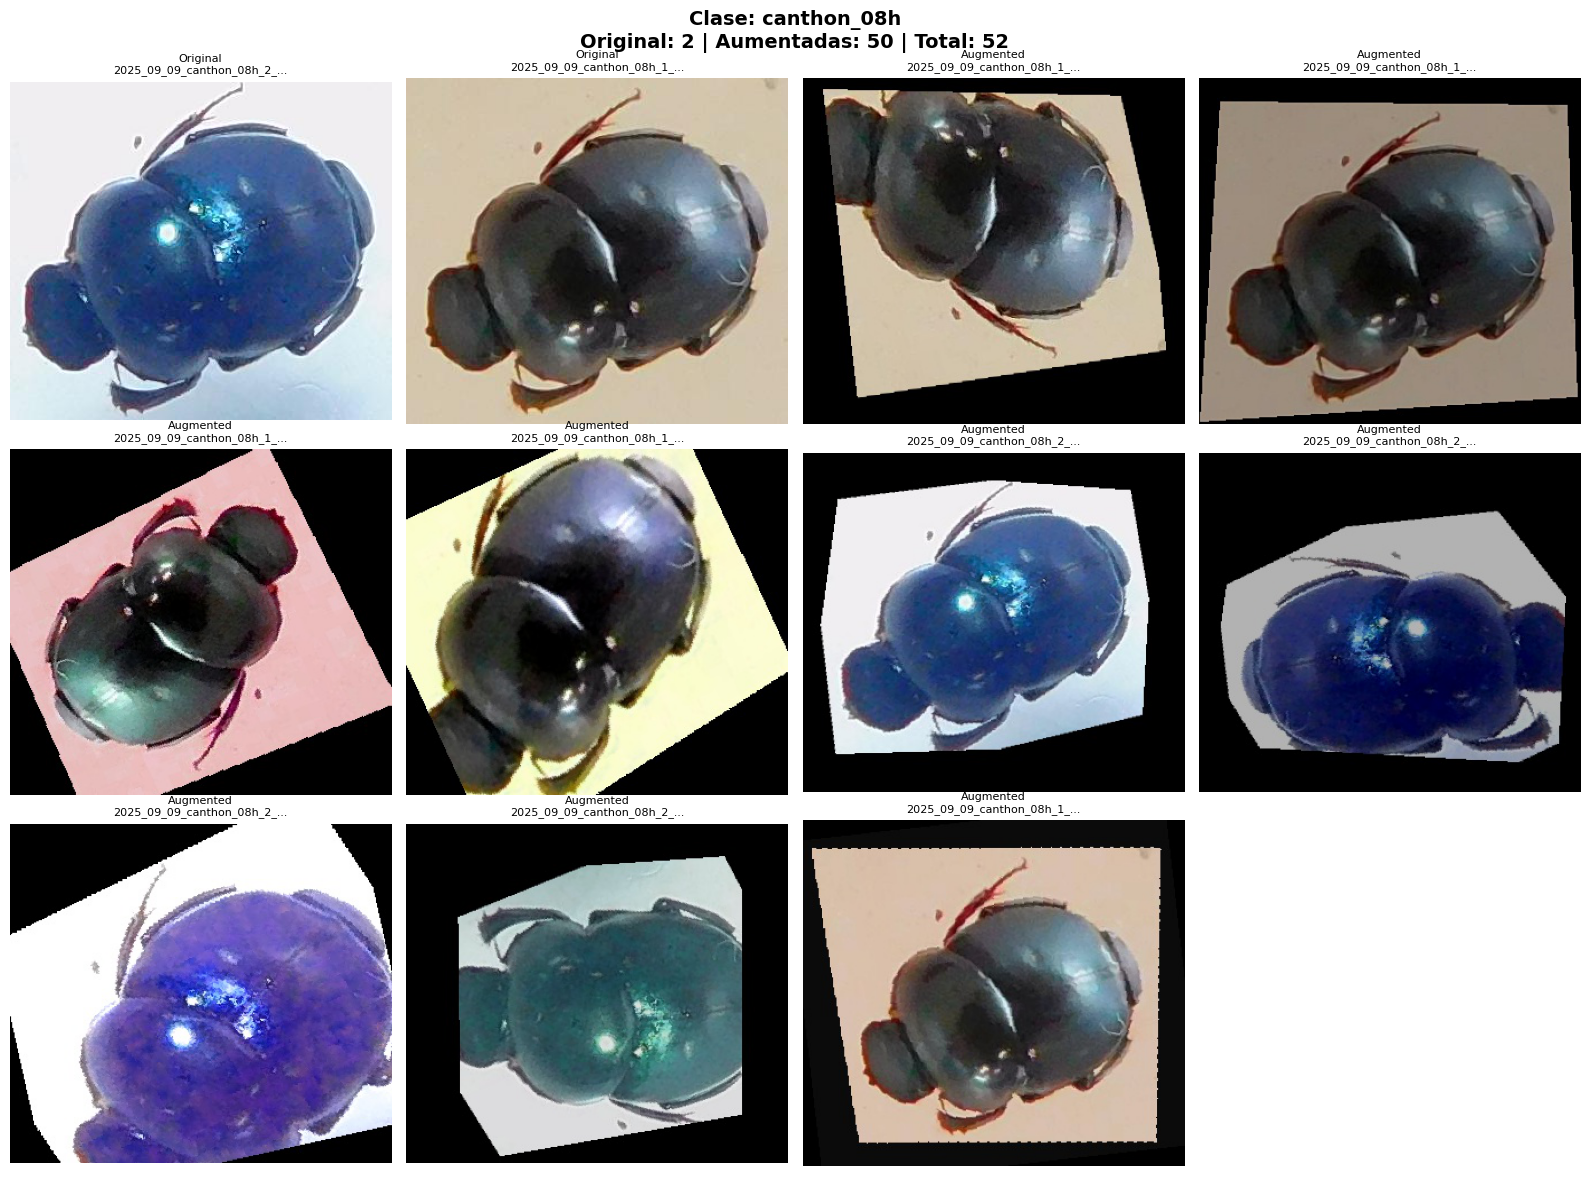

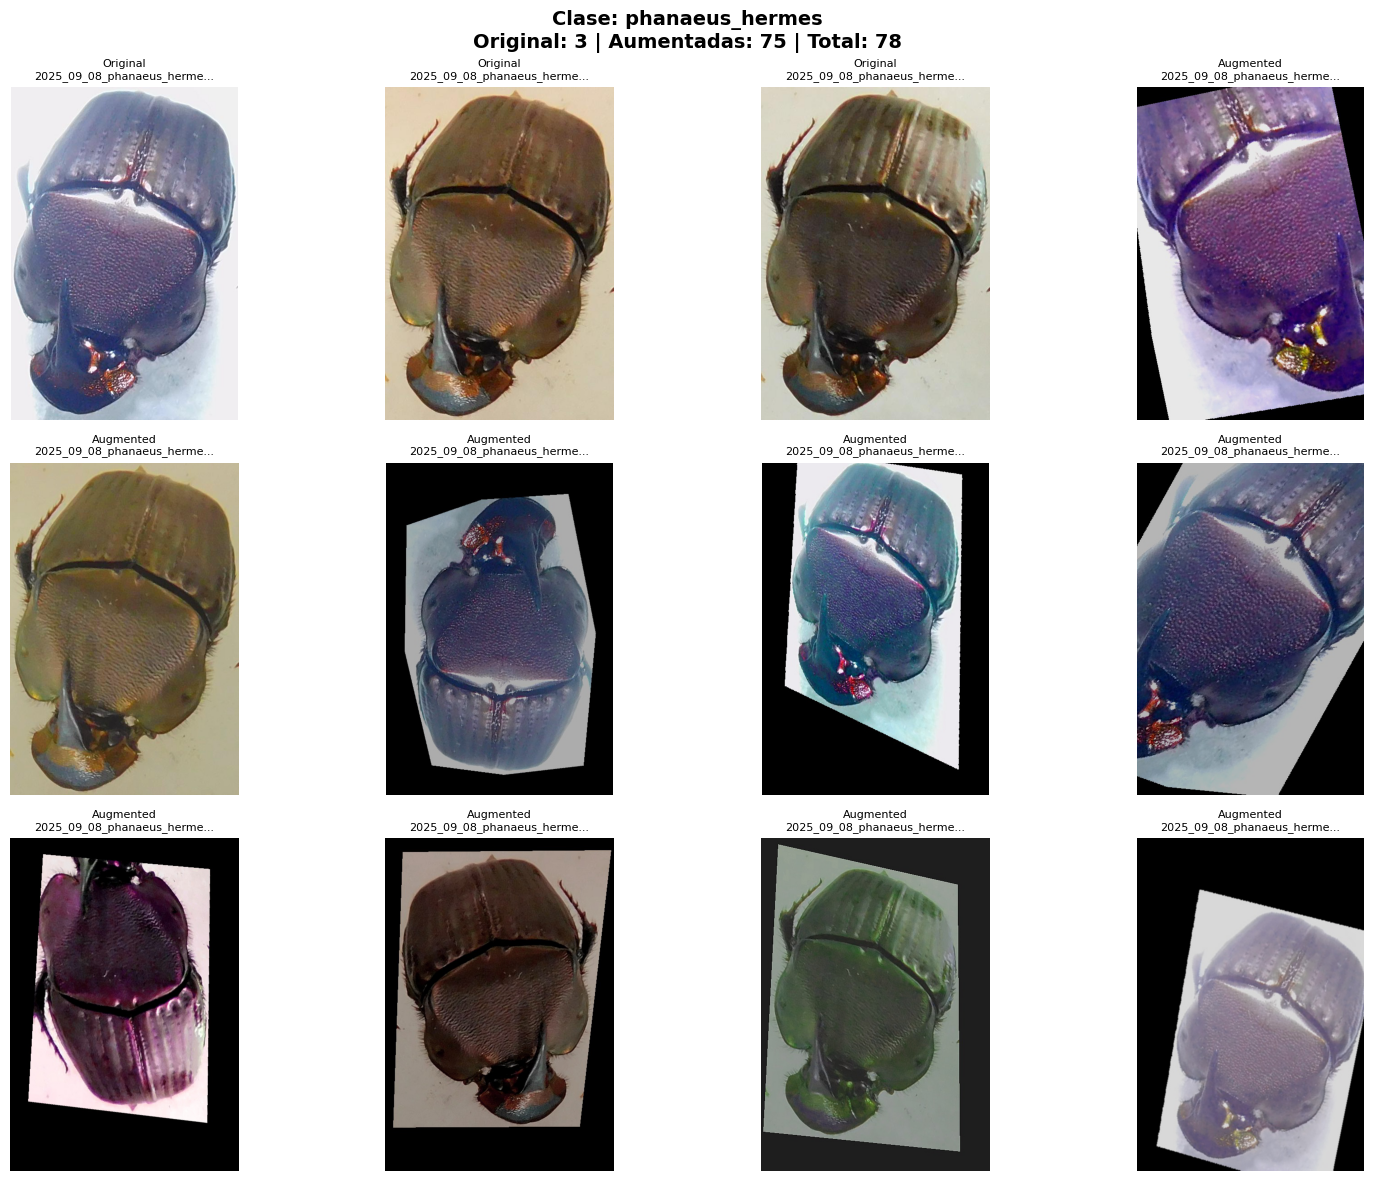

In [12]:
def visualize_augmented_samples(class_name, num_samples=12):
    """
    Visualiza muestras aleatorias de una clase después del augmentation
    """
    # Buscar en la carpeta de AUMENTADAS
    class_path = os.path.join(OUTPUT_DIR, class_name)
    
    # Si no existe la carpeta de aumentadas, buscar en originales
    if not os.path.exists(class_path):
        print(f"⚠️  No se encontró la carpeta aumentada para {class_name}")
        return
    
    # Obtener todas las imágenes aumentadas
    all_images = [f for f in os.listdir(class_path) 
                  if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    
    if len(all_images) == 0:
        print(f"No se encontraron imágenes aumentadas en {class_name}")
        return
    
    # También obtener originales para comparación
    orig_class_path = os.path.join(DATA_DIR, class_name)
    original_images = [f for f in os.listdir(orig_class_path) 
                      if f.lower().endswith(('.jpg', '.jpeg', '.png'))
                      and '_aug_' not in f]
    
    # Seleccionar muestras
    sample_original = random.sample(original_images, min(3, len(original_images)))
    sample_augmented = random.sample(all_images, min(num_samples-3, len(all_images)))
    
    
    # Visualizar
    rows = 3
    cols = 4
    fig, axes = plt.subplots(rows, cols, figsize=(16, 12))
    axes = axes.flatten()
    
    # Mostrar originales primero
    for idx, img_file in enumerate(sample_original):
        img_path = os.path.join(orig_class_path, img_file)
        img = Image.open(img_path)
        
        axes[idx].imshow(img)
        axes[idx].set_title(f"Original\n{img_file[:25]}...", fontsize=8)
        axes[idx].axis('off')
    
    # Luego mostrar aumentadas
    for idx, img_file in enumerate(sample_augmented, start=len(sample_original)):
        if idx >= num_samples:
            break
        img_path = os.path.join(class_path, img_file)
        img = Image.open(img_path)
        
        axes[idx].imshow(img)
        axes[idx].set_title(f"Augmented\n{img_file[:25]}...", fontsize=8)
        axes[idx].axis('off')
    
    # Ocultar ejes sobrantes
    for idx in range(len(sample_original) + len(sample_augmented), len(axes)):
        axes[idx].axis('off')
    
    plt.suptitle(f'Clase: {class_name}\n'
                 f'Original: {len(original_images)} | Aumentadas: {len(all_images)} | '
                 f'Total: {len(original_images) + len(all_images)}', 
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Visualizar algunas clases
print("🖼️  VISUALIZACIÓN DE MUESTRAS AUMENTADAS\n")

# Seleccionar clases para visualizar
classes_to_visualize = []

# Clase con muy pocas imágenes
for class_name, count in sorted(class_dist.items(), key=lambda x: x[1])[:3]:
    if count <= 5:
        classes_to_visualize.append(class_name)

# Clase con pocas imágenes
for class_name, count in class_dist.items():
    if 30 <= count <= 60:
        classes_to_visualize.append(class_name)
        break

# Clase con cantidad media
for class_name, count in class_dist.items():
    if 100 <= count <= 150:
        classes_to_visualize.append(class_name)
        break

# Visualizar
for class_name in classes_to_visualize[:3]:
    visualize_augmented_samples(class_name)